# 1. Business Understanding

## Problem Statement :
* Credit card fraud is a major issue for financial institutions. Fraudulent transactions cause significant financial loss and damage customer trust.

* The dataset contains 284,807 transactions, out of which only 492 are fraud cases (0.172%). This makes the problem highly imbalanced.


## Objective :   
 * Build a Machine Learning model that can accurately detect fraudulent transactions as early as possible.

* Reduce financial losses caused by fraud.

## Challenges :      


1.   Extreme Class Imbalance :    
Fraud cases are only 0.172% of total transactions. A normal accuracy metric can be misleading.


2.   Cost of False Negatives (FN) :  
If a fraud transaction is predicted as normal, the bank loses money.


3. Cost of False Positives (FP) :    
If a genuine transaction is predicted as fraud, the customer may face card blocking.



## Evaluation Concepts

| Term | Prediction | Reality | Impact |
| :--- | :--- | :--- | :--- |
| **True Positive (TP)** | Fraud | Fraud | ✅ **Success:** Fraud detected. |
| **True Negative (TN)** | Normal | Normal | ✅ **Correct:** Legitimate transaction. |
| **False Positive (FP)** | Fraud | Normal | ⚠️ **Type I Error:** Customer blocked/Annoyed. |
| **False Negative (FN)** | Normal | Fraud | ❌ **Type II Error:** Money stolen/Loss! |

> ## Recall -:

Out of all actual fraud cases, how many did we correctly detect?

> ## Precision -:

Out of all transactions predicted as fraud, how many were actually fraud?

# 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import roc_curve, roc_auc_score




# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier

# 3. Data Understanding
Initial exploration of the dataset to examine its structure, features, data types, and overall characteristics before performing analysis or modeling.

## 3.1 Loading the Dataset

In [2]:
data = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3.2 Rows and Columns

In [3]:
print(f"Total Rows are {data.shape[0]}")
print(f"Total Columns are {data.shape[1]}")

Total Rows are 284807
Total Columns are 31


## 3.3 Data Types

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## 3.4 Statistical Summary

In [5]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 3.6 Class Distribution (Imblance Check)

In [6]:
class_counts = data["Class"].value_counts()
class_counts

Class
0    284315
1       492
Name: count, dtype: int64

## 3.7  Fraud Percentage

In [7]:
fraud_percentage = (class_counts[1]/len(data)) * 100
print(f"Fraud Percentage: {fraud_percentage:.4f}%")

Fraud Percentage: 0.1727%


# 4. Exploratory Data Analysis (EDA)
Initial data investigation performed to understand feature distributions, detect patterns, identify outliers, and examine class imbalance before modeling.

## 0.1 Class Imblance Visualization (Percentage View)

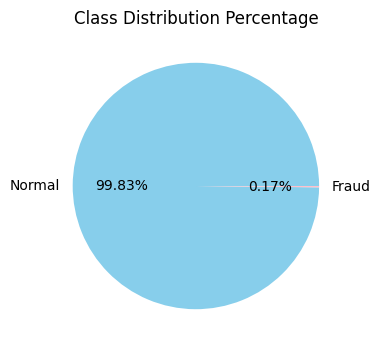

In [8]:
plt.figure(figsize= (6,4))
class_count = data["Class"].value_counts()
labels = ["Normal", "Fraud"]

plt.pie(class_counts, labels = labels, autopct = "%1.2f%%", colors = ["skyblue", "pink"])
plt.title("Class Distribution Percentage")
plt.show()

# 0.2 Fraud vs Non-Fraud Count Plot

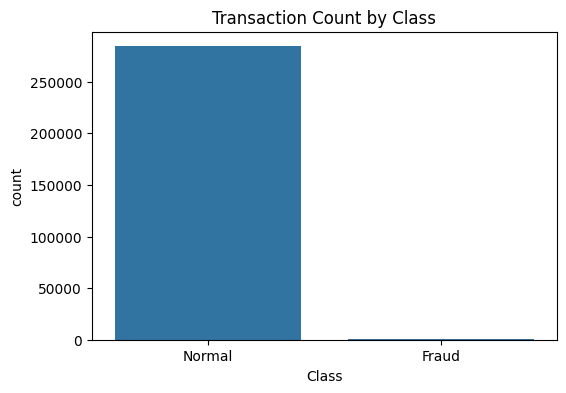

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=data)
plt.title("Transaction Count by Class")
plt.xticks([0,1], ['Normal', 'Fraud'])
plt.show()

## 0.3 Transaction Amount Analysis

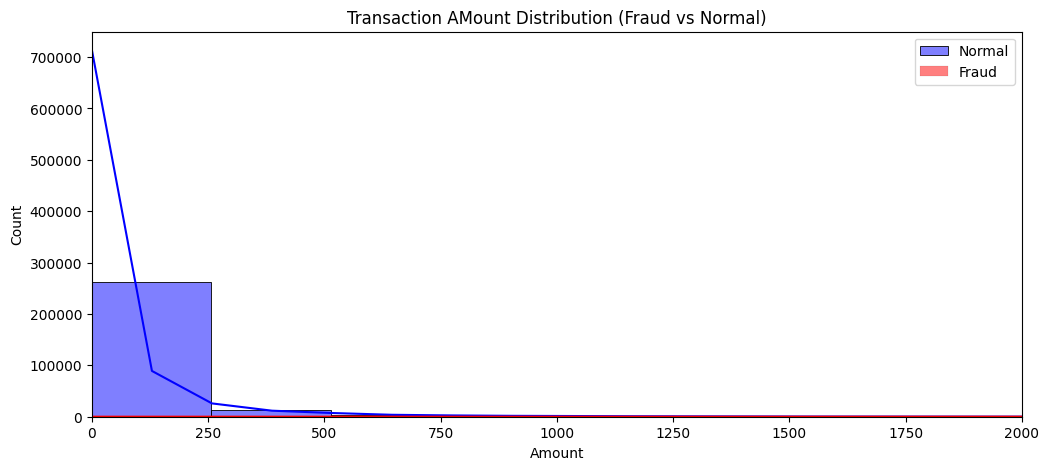

In [10]:
plt.figure(figsize = (12,5))

sns.histplot(data[data["Class"]==0]["Amount"], bins = 100, color = "blue", label = "Normal", kde = True)
sns.histplot(data[data["Class"]==1]["Amount"], bins = 100, color = "red", label = "Fraud", kde = True )

plt.legend()
plt.title("Transaction AMount Distribution (Fraud vs Normal)")
plt.xlim(0, 2000) # Limit For better visibility
plt.show()

## 0.4 Log Transformation of Amount (Better Visualization)

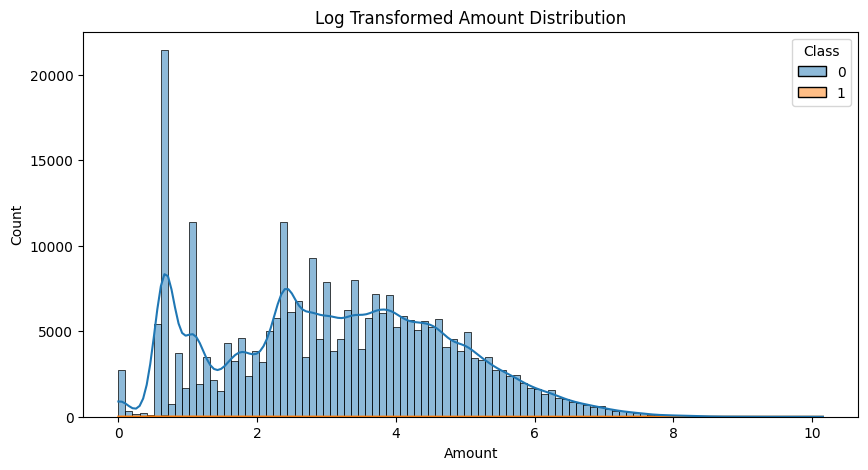

In [11]:
# Log Transformaation

plt.figure(figsize = (10,5))
sns.histplot(data= data, x = np.log1p(data["Amount"]), hue = "Class", bins = 100, kde = True)
plt.title("Log Transformed Amount Distribution")
plt.show()

## 0.5 Time Based Fraud Analysis

Time contains the number of seconds elapsed between each transaction and the first transaction in the dataset.

In [12]:
data["Time"].sample(10)

107463     70446.0
280645    169660.0
29127      35333.0
122516     76593.0
176377    122738.0
187205    127437.0
228449    145515.0
228134    145371.0
259395    159095.0
111809     72380.0
Name: Time, dtype: float64

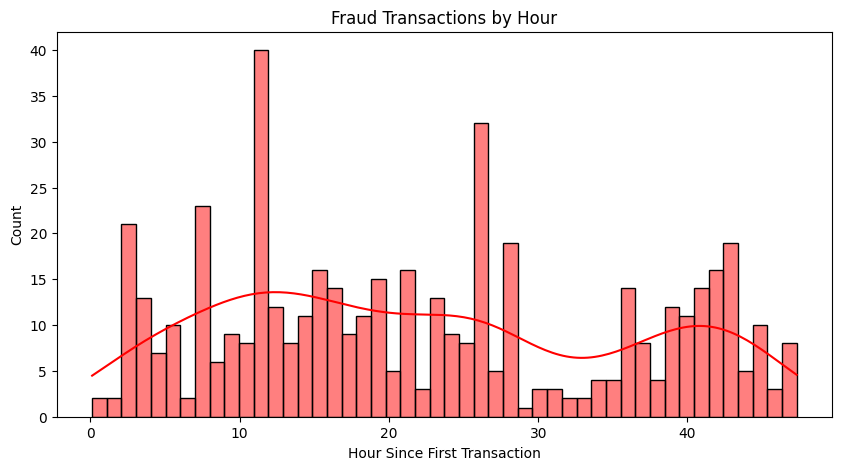

In [13]:
data['Hour'] = data['Time'] / 3600

plt.figure(figsize = (10, 5))
sns.histplot(data[data["Class"]==1]["Hour"], bins = 48, color = "red", kde = True)
plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour Since First Transaction")
plt.ylabel("Count")
plt.show()

In [14]:
data["Hour"].max()

47.99777777777778

In [15]:
data["Hour"]

0          0.000000
1          0.000000
2          0.000278
3          0.000278
4          0.000556
            ...    
284802    47.996111
284803    47.996389
284804    47.996667
284805    47.996667
284806    47.997778
Name: Hour, Length: 284807, dtype: float64

## 0.6 Correlation with Target

- Correlation analysis shows that no single feature strongly predicts fraud, as most correlations are moderate.

- Features such as V17, V14, and V12 show relatively stronger negative correlation with the target variable, indicating their potential importance in fraud detection.

- This suggests that fraud patterns are likely captured through combinations of multiple features rather than a single dominant variable.


In [16]:
corr = data.corr()["Class"].sort_values(ascending=False)
print("Top Postive Correlations: \n", corr.head(10))
print("\nTop Negative Correlations: \n", corr.tail(10))

Top Postive Correlations: 
 Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

Top Negative Correlations: 
 V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


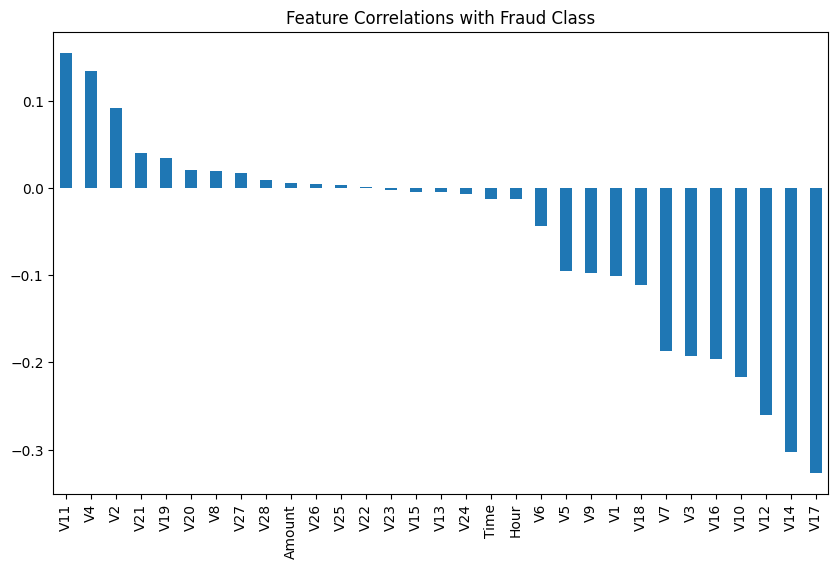

In [17]:
plt.figure(figsize = (10, 6))
corr.drop("Class").plot(kind = "bar")
plt.title("Feature Correlations with Fraud Class")
plt.show()

# 5. Feature  Preparation

## 5.1 Feature Engineering

Minimal feature engineering was required as the dataset was already PCA-transformed (V1–V28). However, the `Amount` feature was log-transformed to reduce skewness.

In [18]:
# Amount log transformation
data["Log_Amount"] = np.log1p(data["Amount"])

## 5.2 Dropping Raw Columns
Raw transaction identifiers and redundant features were removed to reduce noise and prevent data leakage.

In [19]:
data = data.drop(columns = ["Time", "Amount"])
data.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Hour',
       'Log_Amount'],
      dtype='object')

## 5.3 Splitting Features and Target

In [20]:
x = data.drop("Class", axis = 1)
y = data["Class"]

In [21]:
# Shape of the x and y
print("Feature Shape : ", x.shape)
print("Target Shape : ", y.shape)

Feature Shape :  (284807, 30)
Target Shape :  (284807,)


## 5.4 Train Test Split (Stratified)
Stratification ensures class distribution consistency across training and test sets.

In [22]:
xtrain, xtest, ytrain, ytest = train_test_split( x, y, test_size = 0.4, random_state = 42 ,stratify = y)

xtrain.shape, xtest.shape, ytrain.shape, ytest.shape

((170884, 30), (113923, 30), (170884,), (113923,))

## 5.5 Scaling Feature
StandardScaler was applied to normalize feature values by transforming them to have a mean of 0 and a standard deviation of 1, ensuring consistent scale across variables for model training.

In [23]:
scaler = StandardScaler()
minmax = MinMaxScaler()

xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

In [24]:
xtrain_scaled

array([[-1.07708905,  0.71315589,  1.06420009, ...,  0.68372286,
        -0.50025441, -0.06738363],
       [ 1.18008509, -0.79111933, -0.93384544, ..., -0.2432157 ,
         1.57333232, -0.23140098],
       [ 1.0733831 ,  0.09671229, -0.92176196, ..., -0.1715517 ,
         0.340745  , -1.48782087],
       ...,
       [-0.76557084,  0.40104415,  1.04265876, ...,  0.14316881,
        -0.71938198,  0.29108031],
       [ 0.54501968,  0.04634945,  0.32847028, ...,  0.07868971,
        -1.25537097,  0.41216853],
       [-0.30629548,  0.47195684,  1.20183415, ...,  0.65534171,
        -1.39122585, -0.65096335]])

# 6. Modeling


## 6.1 Baseline Model Comparison
Multiple machine learning models were initially evaluated using Stratified Cross-Validation to compare their baseline performance and identify the most promising algorithms for further optimization.

### 6.1.1 Defining Model Dictionary
(Logistic, RF, GB, SVM, XGB)

In [25]:
models = {
    "Logistic Regression" : LogisticRegression(class_weight="balanced", max_iter = 1000),
    "Random Forest" : RandomForestClassifier(class_weight = "balanced", n_estimators=100, random_state=42),
    "Gradient Boosting" : GradientBoostingClassifier(random_state = 42),
    "SVM" : SVC(class_weight = "balanced", probability = True, random_state = 42),
    "XGBoost" : XGBClassifier( random_state = 42, eval_metric = "logloss")

}

### 6.1.2 Stratified k-Fold Cross Validation
StratifiedKFold was used to maintain class imbalance ratio across folds.

In [26]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

### 6.1.3 Cross Validation Results
comparison_df sorted by PR-AUC

In [27]:
results = []

for name, model in models.items():

  print("="*60)
  print(f"Model:  {name}")
  print("="*60)

  precision_scores = []
  recall_scores = []
  f1_scores = []
  roc_auc_scores = []
  pr_auc_scores = []
    

  for train_index, val_index in skf.split(xtrain_scaled, ytrain):

    x_fold_train = xtrain_scaled[train_index]
    x_fold_val = xtrain_scaled[val_index]
    y_fold_train = ytrain.iloc[train_index]
    y_fold_val = ytrain.iloc[val_index]


    model.fit(x_fold_train, y_fold_train)

    y_pred = model.predict(x_fold_val)
    y_proba = model.predict_proba(x_fold_val)[:,1]

    precision_scores.append(precision_score(y_fold_val, y_pred))
    recall_scores.append(recall_score(y_fold_val, y_pred))
    f1_scores.append(f1_score(y_fold_val, y_pred))
    roc_auc_scores.append(roc_auc_score(y_fold_val, y_proba))
    pr_auc_scores.append(average_precision_score(y_fold_val, y_proba))
    cm = confusion_matrix(y_fold_val, y_pred)
    c = classification_report(y_fold_val, y_pred)


  print(f"Average Precision: {np.mean(precision_scores):.4f}")
  print(f"Average Recall: {np.mean(recall_scores):.4f}")
  print(f"Average F1 Score: {np.mean(f1_scores):.4f}")
  print(f"Average ROC AUC Score: {np.mean(roc_auc_scores):.4f}")
  print(f"Average PR AUC Score: {np.mean(pr_auc_scores):.4f}")
  print("Comfusion Matrix\n")
  print(cm)
  print(c)
  print("\n")

  results.append({
        "Model": name,
        "Precision": np.mean(precision_scores),
        "Recall": np.mean(recall_scores),
        "F1 Score": np.mean(f1_scores),
        "ROC-AUC": np.mean(roc_auc_scores),
        "PR-AUC": np.mean(pr_auc_scores)
  })

# Result Dataframe
comparison_df = pd.DataFrame(results)



Model:  Logistic Regression
Average Precision: 0.0616
Average Recall: 0.9085
Average F1 Score: 0.1154
Average ROC AUC Score: 0.9711
Average PR AUC Score: 0.7641
Comfusion Matrix

[[33396   721]
 [    7    52]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     34117
           1       0.07      0.88      0.12        59

    accuracy                           0.98     34176
   macro avg       0.53      0.93      0.56     34176
weighted avg       1.00      0.98      0.99     34176



Model:  Random Forest
Average Precision: 0.9411
Average Recall: 0.7458
Average F1 Score: 0.8312
Average ROC AUC Score: 0.9445
Average PR AUC Score: 0.8369
Comfusion Matrix

[[34115     2]
 [   15    44]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     34117
           1       0.96      0.75      0.84        59

    accuracy                           1.00     34176
   macro avg       0.98      0.87      

## 6.2 Model Selection for Advanced Tuning
Based on baseline performance, `Random Forest` and `XGBoost` showed superior F1-score and PR-AUC. Therefore, these models were selected for further optimization.

In [28]:
comparision_df = comparison_df.sort_values(by="PR-AUC", ascending=False)
comparision_df

,Model,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
1,Random Forest,0.941062,0.745763,0.831247,0.944469,0.836929
0,Logistic Regression,0.061634,0.908475,0.115385,0.971129,0.764079
3,SVM,0.428405,0.691525,0.527843,0.966145,0.557895
2,Gradient Boosting,0.778682,0.477966,0.578456,0.632963,0.435952
4,XGBoost,0.031867,0.044068,0.035696,0.413698,0.005674


## 6.3 Random Forest Modeling
Random Forest was selected for further experimentation due to its strong baseline performance and ability to handle non-linear relationships and feature interactions.

### 6.3.1 Hyperparameter Tuning (Without SMOTE)
Hyperparameter tuning was performed using GridSearchCV to identify the optimal Random Forest configuration using the original imbalanced training data.

In [29]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators" : [100],
    "max_depth" : [None, 10],
    "min_samples_leaf" : [1,2]
}

rf = RandomForestClassifier(class_weight = "balanced", random_state = 42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions = param_grid,
    n_iter = 10,
    cv = 5,
    scoring = "average_precision",
    n_jobs = -1,
    random_state = 42
)

random_search.fit(xtrain_scaled, ytrain)
best_model_rf = random_search.best_estimator_
print("Best Params: ", random_search.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Params:  {'n_estimators': 100, 'min_samples_leaf': 2, 'max_depth': None}


### 6.3.2 Threshold Optimization Function

Since fraud detection is a highly imbalanced classification problem, the classification threshold was tuned to improve the balance between precision and recall.

In [36]:
#n Threshold Tunning Function

def threshold_tunning(ytest, y_proba, model_name, thresholds = [0.1,0.2,0.3,0.4,0.5]):

    best_threshold = 0
    best_f1 = 0

    for t in thresholds:

        y_pred = (y_proba >= t).astype(int)

        # Metrics
        precision = precision_score(ytest, y_pred)
        recall = recall_score(ytest, y_pred)
        f1 = f1_score(ytest, y_pred)
        cm = confusion_matrix(ytest, y_pred)

        print(f"\n Threshold: {t:.2f}")
        print("Precision :", round(precision, 3))
        print("Recall: ", round(recall, 3))
        print("F1 Score: ", round(f1, 3))
        print(cm)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t
            best_p = precision
            best_r = recall
            best_cm = cm

    roc_auc =roc_auc_score(ytest , y_proba)

    print("\n")
    print("=" * 30)
    print(f"{model_name}")
    print("Best Threshold: ", best_threshold)
    print("Best F1: ", round(best_f1, 3))
    print(best_cm)

    return best_threshold, best_f1, best_p, best_r, roc_auc, best_cm      
        

### 6.3.3 Evaluation & Threshold optimization on RandomForest Test set
The tuned Random Forest model was evaluated on the unseen test dataset using ROC-AUC, F1-score, and confusion matrix.

In [38]:
y_proba_rf = random_search.predict_proba(xtest_scaled)[:,1]

best_t, f1, precision, recall, roc, cm = threshold_tunning(ytest, y_proba_rf,"Random Forest Tuned")


 Threshold: 0.10
Precision : 0.705
Recall:  0.848
F1 Score:  0.77
[[113656     70]
 [    30    167]]

 Threshold: 0.20
Precision : 0.839
Recall:  0.817
F1 Score:  0.828
[[113695     31]
 [    36    161]]

 Threshold: 0.30
Precision : 0.872
Recall:  0.797
F1 Score:  0.833
[[113703     23]
 [    40    157]]

 Threshold: 0.40
Precision : 0.923
Recall:  0.792
F1 Score:  0.852
[[113713     13]
 [    41    156]]

 Threshold: 0.50
Precision : 0.955
Recall:  0.756
F1 Score:  0.844
[[113719      7]
 [    48    149]]


Random Forest Tuned
Best Threshold:  0.4
Best F1:  0.852
[[113713     13]
 [    41    156]]


### 6.3.4 ROC Curve

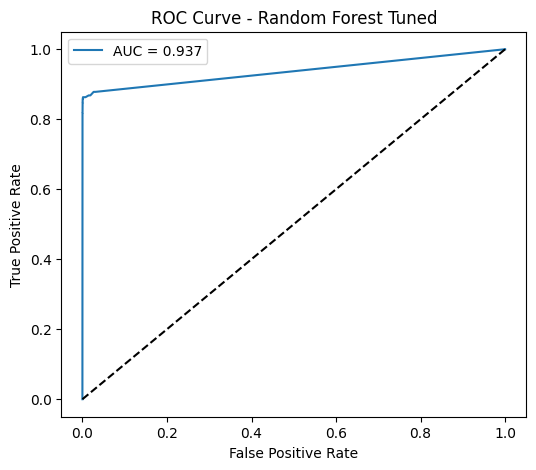

In [39]:
# Roc Curve
fpr_rf, tpr_rf, _ = roc_curve(ytest, y_proba_rf)
# AUC Score
auc_rf = roc_auc_score(ytest, y_proba_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.3f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Tuned")
plt.legend()

plt.show()


### 6.3.5 Appending Results

In [40]:
final_results = []

final_results.append([
   "Random Forest Tuned",
    f1,
    precision,
    recall,
    roc,
    cm
])

## 6.4 Random Forest with SMOTE
To address severe class imbalance in the dataset, SMOTE (Synthetic Minority Over-sampling Technique) was applied to the training data. 

This approach synthetically generates minority class samples to improve the model’s ability to detect fraudulent transactions.


### 6.4.1 Applying SMOTE (Traning Data Only)
SMOTE was applied only to the training dataset to avoid data leakage and ensure that the test set remains a true representation of unseen data.

In [41]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(xtrain_scaled, ytrain)

print("Before SMOTE:", ytrain.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: Class
0    170589
1       295
Name: count, dtype: int64
After SMOTE: Class
0    170589
1    170589
Name: count, dtype: int64


### 6.4.2 Train RF (No Class Weights)
After balancing the dataset using SMOTE, Random Forest was trained on the resampled training data. 
Class weights were removed because SMOTE already balances the class distribution.

In [43]:
rf_smote = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=2,
    max_depth=None,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier(min_samples_leaf=2, random_state=42)

### 6.4.3 Evaluation & Threshold Optimization on RF + SMOTE on Test Set

The model trained on SMOTE-balanced data was evaluated on the original imbalanced test dataset to measure its real-world performance.

In [44]:
y_proba_rf_smote = rf_smote.predict_proba(xtest_scaled)[:,1]

best_t, f1, precision, recall, roc, cm = threshold_tunning(ytest, y_proba_rf_smote,"Random Forest + SMOTE")


 Threshold: 0.10
Precision : 0.28
Recall:  0.878
F1 Score:  0.425
[[113281    445]
 [    24    173]]

 Threshold: 0.20
Precision : 0.591
Recall:  0.858
F1 Score:  0.7
[[113609    117]
 [    28    169]]

 Threshold: 0.30
Precision : 0.739
Recall:  0.848
F1 Score:  0.79
[[113667     59]
 [    30    167]]

 Threshold: 0.40
Precision : 0.817
Recall:  0.817
F1 Score:  0.817
[[113690     36]
 [    36    161]]

 Threshold: 0.50
Precision : 0.87
Recall:  0.812
F1 Score:  0.84
[[113702     24]
 [    37    160]]


Random Forest + SMOTE
Best Threshold:  0.5
Best F1:  0.84
[[113702     24]
 [    37    160]]


### 6.4.4 ROC Curve

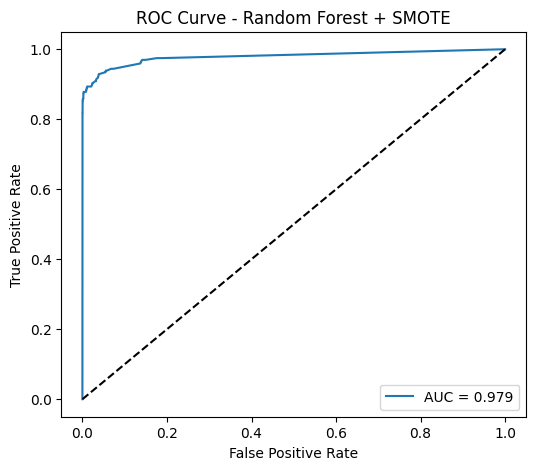

In [45]:
# ROC Curve
fpr_rf_smote, tpr_rf_smote, _ = roc_curve(ytest, y_proba_rf_smote)

# AUC Curve
auc_rf_smote = roc_auc_score(ytest, y_proba_rf_smote)

plt.figure(figsize=(6,5))

plt.plot(fpr_rf_smote, tpr_rf_smote, label=f"AUC = {auc_rf_smote:.3f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest + SMOTE")
plt.legend()

plt.show()

### 6.4.5 Appending Result

In [46]:
final_results.append([
   "Random Forest + SMOTE",
    f1,
    precision,
    recall,
    roc,
    cm
])

## 6.5 XGBOOSt Modeling
XGBoost was implemented as an advanced gradient boosting algorithm to capture complex patterns in the data and improve fraud detection performance.

### 6.5.1 Handling Class Imbalance using scale_pos_weight

The scale_pos_weight parameter in XGBoost was adjusted to account for the imbalance between fraudulent and non-fraudulent transactions, giving higher importance to the minority (fraud) class during training.

In [47]:
neg = ytrain.value_counts()[0]
pos = ytrain.value_counts()[1]

scale_pos_weight = neg/pos
print(scale_pos_weight)

578.2677966101695


### 6.5.2 Defining the XGBoost Model

In [48]:
xgb = XGBClassifier(
    objective = "binary:logistic",
    scale_pos_weight = scale_pos_weight,
    eval_metric = "logloss",
    random_state = 42
)

### 6.5.3 Different Parameter Grid
Loading various parameters

In [49]:
param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 3, 5]
}

### 6.5.4 Hyperparameter Tunning using RandomizedSearchCV

In [50]:
import warnings
warnings.filterwarnings("ignore")

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,              # keep 30-40 (good balance)
    scoring='roc_auc',      # IMPORTANT
    cv=3,                   # 3-fold stratified
    verbose=1,
    random_state=42,
    n_jobs=-1
) 

random_search.fit(xtrain_scaled, ytrain)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 7],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 400, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

### 6.5.4 Evaluation & Threshold Optimization (XGB)

In [51]:
y_proba_xgb = random_search.predict_proba(xtest_scaled)[:,1]

best_t, f1, precision, recall, roc, cm = threshold_tunning(ytest, y_proba_xgb, "XGBoost Tunned")


 Threshold: 0.10
Precision : 0.589
Recall:  0.853
F1 Score:  0.697
[[113609    117]
 [    29    168]]

 Threshold: 0.20
Precision : 0.719
Recall:  0.843
F1 Score:  0.776
[[113661     65]
 [    31    166]]

 Threshold: 0.30
Precision : 0.764
Recall:  0.822
F1 Score:  0.792
[[113676     50]
 [    35    162]]

 Threshold: 0.40
Precision : 0.809
Recall:  0.817
F1 Score:  0.813
[[113688     38]
 [    36    161]]

 Threshold: 0.50
Precision : 0.829
Recall:  0.812
F1 Score:  0.821
[[113693     33]
 [    37    160]]


XGBoost Tunned
Best Threshold:  0.5
Best F1:  0.821
[[113693     33]
 [    37    160]]


### 6.5.5 ROC Curve 

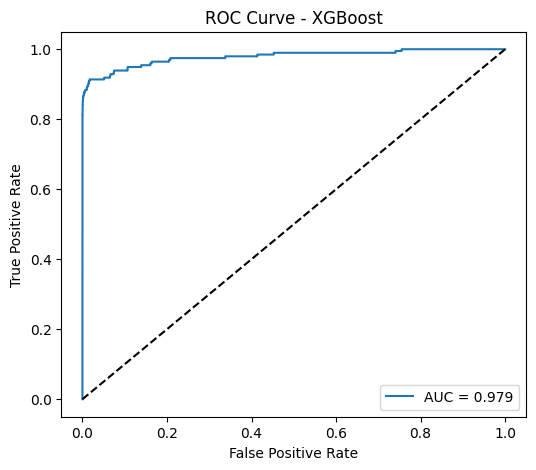

In [52]:
# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(ytest, y_proba_xgb)

# AUC Scores
auc_xgb = roc_auc_score(ytest, y_proba_xgb)

plt.figure(figsize=(6,5))

plt.plot(fpr_xgb, tpr_xgb, label=f"AUC = {auc_xgb:.3f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.show()

### 6.5.6 Appending Result

In [53]:
final_results.append([
   "XGBoost Tunned",
    f1,
    precision,
    recall,
    roc,
    cm
])

## 6.6 Ensemble (XGBoost + Random Forest)
A soft voting ensemble combining Random Forest and XGBoost was implemented to levarage the strengths of both models and potentially improve overall prediction performance.

### 6.6.2 Loading RF and XGB
Tunned Models

In [54]:
# Tuned XGboost
xgb_model = XGBClassifier(
    n_estimators = 300,
    max_depth = 20,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42,
    eval_metric = "logloss"
    
)

# Tuned Random Forest
rf_model = RandomForestClassifier(
    n_estimators = 300,
    max_depth = None,
    class_weight = "balanced",
    random_state = 42,
    n_jobs = -1
)


### 6.6.1 Creating Soft Voting 
A soft voting ensemble classifier was created by combining Random Forest and XGBoost, where predicted probabilities from both models are averaged to produce the final prediction

In [55]:
# Voting Classifier

ensemble_model = VotingClassifier(
    estimators = [
        ("xgb", xgb_model),
        ("rf", rf_model)
    ],
    voting= "soft",
    flatten_transform=True,
    n_jobs = -1
    
)

### 6.6.3 Training Ensemble

In [56]:
ensemble_model.fit(xtrain_scaled, ytrain)

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_con...
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=20,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42))],
                 n_jobs=-1, voting='soft')

### 6.6.4 Evaluation & Threshold Optimization (Ensemble)

In [57]:
y_proba_ens = ensemble_model.predict_proba(xtest_scaled)[:,1]

best_t, f1, precision, recall, roc, cm = threshold_tunning(ytest, y_proba_ens, "Ensemble Model")


 Threshold: 0.10
Precision : 0.855
Recall:  0.838
F1 Score:  0.846
[[113698     28]
 [    32    165]]

 Threshold: 0.20
Precision : 0.908
Recall:  0.802
F1 Score:  0.852
[[113710     16]
 [    39    158]]

 Threshold: 0.30
Precision : 0.935
Recall:  0.797
F1 Score:  0.86
[[113715     11]
 [    40    157]]

 Threshold: 0.40
Precision : 0.95
Recall:  0.777
F1 Score:  0.855
[[113718      8]
 [    44    153]]

 Threshold: 0.50
Precision : 0.955
Recall:  0.761
F1 Score:  0.847
[[113719      7]
 [    47    150]]


Ensemble Model
Best Threshold:  0.3
Best F1:  0.86
[[113715     11]
 [    40    157]]


### 6.6.4 ROC Curve


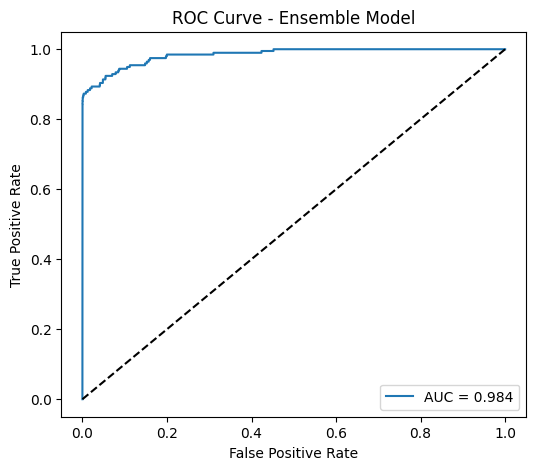

In [58]:
# ROC Curve
fpr_ens, tpr_ens, _ = roc_curve(ytest, y_proba_ens)

# AUC Curve
auc_ens = roc_auc_score(ytest, y_proba_ens)

plt.figure(figsize=(6,5))

plt.plot(fpr_ens, tpr_ens, label=f"AUC = {auc_ens:.3f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Ensemble Model")
plt.legend()

plt.show()

### 6.6.5 Appending Results

In [59]:
final_results.append([
   "Ensemble (RF + XGB)",
    f1,
    precision,
    recall,
    roc,
    cm
])

# 7. Final Model Comparasion Table

Multiple modeling strategies were evaluated including tuned Random Forest, Random Forest with SMOTE, tuned XGBoost, and an ensemble model combining Random Forest and XGBoost.  

Models were compared using F1-score, Precision, Recall, and ROC-AUC due to the highly imbalanced nature of the fraud detection problem.

In [62]:
final_df = pd.DataFrame(
    final_results,
    columns = ["Models", "F1", "Precision","Recall", "ROC_AUC", "Confusion Matrix"]
)

final_df.sort_values("Recall", ascending = False)


,Models,F1,Precision,Recall,ROC_AUC,Confusion Matrix
1,Random Forest + SMOTE,0.839895,0.869565,0.812183,0.978930,"[[113702, 24], [37, 160]]"
2,XGBoost Tunned,0.820513,0.829016,0.812183,0.978535,"[[113693, 33], [37, 160]]"
3,Ensemble (RF + XGB),0.860274,0.934524,0.796954,0.984269,"[[113715, 11], [40, 157]]"
0,Random Forest Tuned,0.852459,0.923077,0.791878,0.936873,"[[113713, 13], [41, 156]]"


> The ensemble model achieved the highest F1-score and ROC-AUC, While Random Forest model trained on SMOTE-balanced data achieved the highest recall while maintaining strong F1-score and ROC-AUC performance.
> 
> Indicating the best balance between precision and recall for fraud detection.

# 8. ROC Curve Comparision Plot

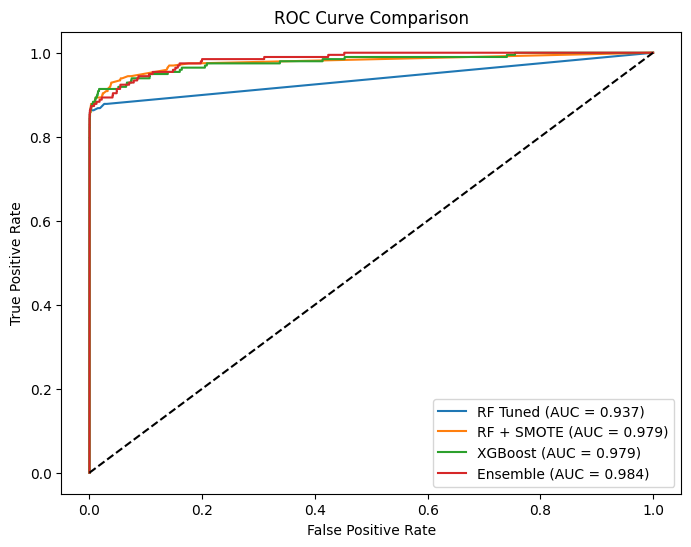

In [63]:
# ROC Curves
fpr_rf, tpr_rf, _ = roc_curve(ytest, y_proba_rf)
fpr_rf_smote, tpr_rf_smote, _ = roc_curve(ytest, y_proba_rf_smote)
fpr_xgb, tpr_xgb, _ = roc_curve(ytest, y_proba_xgb)
fpr_ens, tpr_ens, _ = roc_curve(ytest, y_proba_ens)

# AUC Scores
auc_rf = roc_auc_score(ytest, y_proba_rf)
auc_rf_smote = roc_auc_score(ytest, y_proba_rf_smote)
auc_xgb = roc_auc_score(ytest, y_proba_xgb)
auc_ens = roc_auc_score(ytest, y_proba_ens)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_rf, tpr_rf, label=f"RF Tuned (AUC = {auc_rf:.3f})")
plt.plot(fpr_rf_smote, tpr_rf_smote, label=f"RF + SMOTE (AUC = {auc_rf_smote:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot(fpr_ens, tpr_ens, label=f"Ensemble (AUC = {auc_ens:.3f})")

plt.plot([0,1],[0,1],'k--')  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# 9. Final Model Selection

Since the primary objective of this project is to detect fraudulent transactions, recall was considered the most important metric. A higher recall ensures that fewer fraudulent transactions are missed.

Among all models evaluated, the Random Forest model trained on SMOTE-balanced data achieved the highest recall while maintaining strong F1-score and ROC-AUC performance.

Therefore, the Random Forest + SMOTE model was selected as the final model for fraud detection.

In [72]:
rf_smote_df = final_df[final_df["Models"] == "Random Forest + SMOTE"]
rf_smote_df

,Models,F1,Precision,Recall,ROC_AUC,Confusion Matrix
1,Random Forest + SMOTE,0.839895,0.869565,0.812183,0.97893,"[[113702, 24], [37, 160]]"


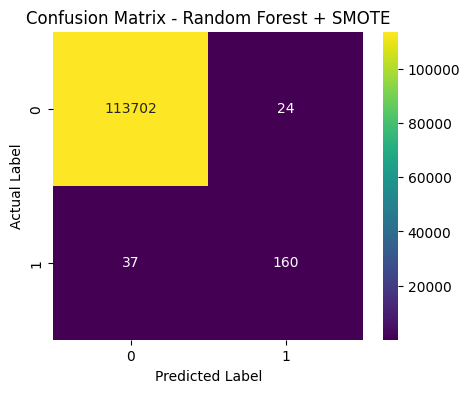

In [83]:
cm = [[113702, 24], [37, 160]]

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest + SMOTE")

plt.show()

- The model successfully detected 160 fraudulent transactions while missing 37 cases.
- Additionally, only 24 normal transactions were incorrectly classified as fraud.
- This demonstrates the model’s strong ability to identify fraudulent activities while maintaining a low false positive rate.

# 10. Saving Final Model

In [79]:
import joblib

# Saving FInal Model
joblib.dump(rf_smote, "credit_card_fraud_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully
